<a href="https://colab.research.google.com/github/Keshav-Agrawal654/Keshav_23FE10CSE00810_MLlab/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Path to dataset files: TCGA_GBM_LGG_Mutations_all.csv
Successfully loaded into a DataFrame. Here are the first 5 rows:


,Grade,Project,Case_ID,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,LGG,TCGA-LGG,TCGA-DU-8164,Male,51 years 108 days,"Oligodendroglioma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,...,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,TCGA-LGG,TCGA-QH-A6CY,Male,38 years 261 days,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
2,LGG,TCGA-LGG,TCGA-HW-A5KM,Male,35 years 62 days,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,LGG,TCGA-LGG,TCGA-E1-A7YE,Female,32 years 283 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
4,LGG,TCGA-LGG,TCGA-S9-A6WG,Male,31 years 187 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


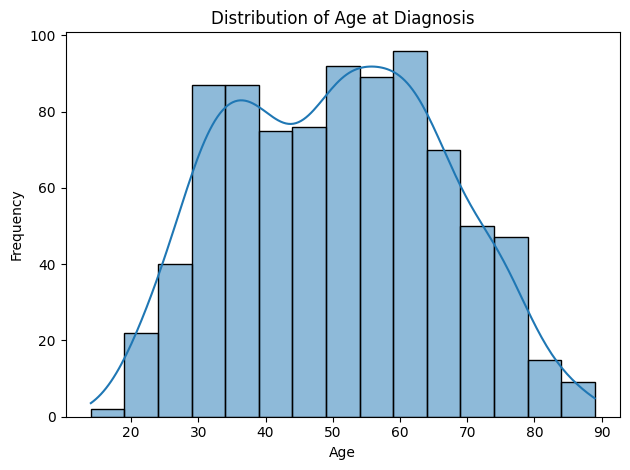

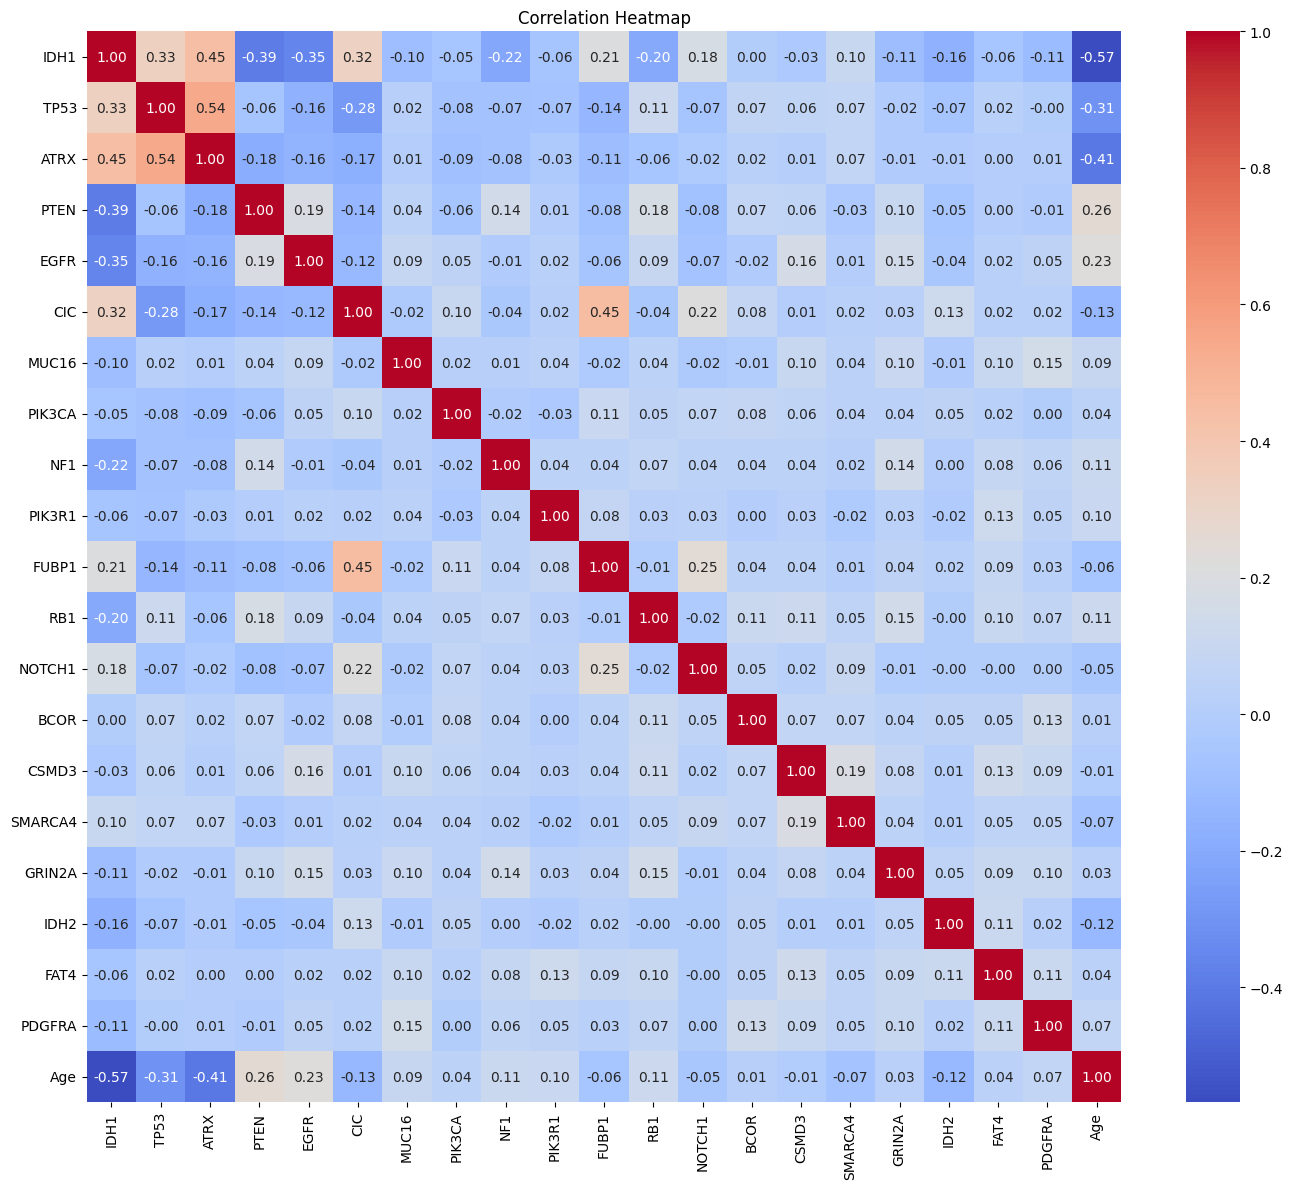

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ── Helper & constants ──────────────────────────────────────────
def parse_age(s):
    m = re.search(r'(\d+)\s*years?', str(s))
    return int(m.group(1)) if m else None

mut_cols = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
            'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
            'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']

# ── Load Data ───────────────────────────────────────────────────
df = pd.read_csv("TCGA_GBM_LGG_Mutations_all.csv")
print("Path to dataset files: TCGA_GBM_LGG_Mutations_all.csv")
print("Successfully loaded into a DataFrame. Here are the first 5 rows:")
display(df.head())

# ── Feature Engineering ─────────────────────────────────────────
df['Age'] = df['Age_at_diagnosis'].apply(parse_age)
for c in mut_cols:
    df[c] = (df[c] == 'MUTATED').astype(int)

# ── Age Distribution ────────────────────────────────────────────
sns.histplot(df['Age'].dropna(), kde=True)
plt.title('Distribution of Age at Diagnosis')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ── Correlation Heatmap ─────────────────────────────────────────
numeric_df = df[mut_cols + ['Age']].dropna()
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()